<a href="https://colab.research.google.com/github/Tanmay-Somani/100daysof-code/blob/main/Main_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [136]:
import os
import glob
import re
import logging
from datetime import datetime
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import random
from torchsummary import summary
from skimage.metrics import peak_signal_noise_ratio as psnr_metric, structural_similarity as ssim_metric

In [157]:
SEQ_LEN = 7
PRED_STEPS = 1
FULL_IMG_SIZE = 1500
IMG_SIZE=64
BATCH_SIZE = 1
EPOCHS = 2 # Increased epochs to allow early stopping to kick in
LR = 5e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED=42

TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15 # Remaining for test (0.15)

In [138]:
BASE_DIR = "/content/project"

os.makedirs(BASE_DIR, exist_ok=True)

DATA_ROOT = f"{BASE_DIR}/data"
LOG_PATH = f"{BASE_DIR}/logs"
LOG_FILE=LOG_PATH+ "/train_cropped.log"
MODEL_PATH = f"{BASE_DIR}/models"
CHKPOINT_DIR = f"{MODEL_PATH}/checkpoints"
IMAGES_DIR = f"{BASE_DIR}/images" # New: Define images directory

for p in [DATA_ROOT, LOG_PATH, MODEL_PATH, CHKPOINT_DIR, IMAGES_DIR]: # New: Add IMAGES_DIR
    os.makedirs(p, exist_ok=True)

In [139]:
runno_file_path = LOG_PATH + '/runno.txt'

# Check if runno.txt exists, if not, create it and initialize with 0
if not os.path.exists(runno_file_path):
    with open(runno_file_path, 'w') as f:
        f.write('0')

# Now, read, increment, and write the run number
with open(runno_file_path, 'r') as R:
    runno = int(R.read())
with open(runno_file_path, 'w') as W:
    W.write(str(int(runno + 1)))

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s",
                    handlers=[logging.FileHandler(LOG_FILE),
                              logging.StreamHandler()])

In [140]:

def set_seed(seed):
    """
    Sets the seeds for `random`, `numpy`, and `torch` libraries to ensure reproducibility.

    Args:
        seed (int): The seed value to be used.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

In [141]:




def parse_datetime(path):
    """
    Parses a datetime string from a file path.

    The file path is expected to be in the format "MMWYY_HHMM" or "MWWYY_HHMM", where:
        - MM: Month as a two-digit number (01-12)
        - W: Weekday (JAN-FEB etc.)
        - YY: Year as a four-digit number
        - HH: Hour in 24-hour format (00-23)
        - MM: Minute (00-59)

    Args:
        path (str): The file path to parse the datetime from.

    Returns:
        datetime: A datetime object representing the parsed date and time.

    Raises:
        ValueError: If the file path does not match the expected format.
    """
    name = os.path.basename(path)
    pattern = r"(\d{2})(\w{3})(\d{4})_(\d{4})"
    match = re.search(pattern, name)
    if not match:
        raise ValueError(f"Bad filename: {name}")
    month_map = {
        'JAN': '01','FEB': '02','MAR': '03','APR': '04','MAY': '05','JUN': '06',
        'JUL': '07','AUG': '08','SEP': '09','OCT': '10','NOV': '11','DEC': '12'
    }
    day=match.group(1)
    month = match.group(2)
    year=match.group(3)
    time=match.group(4)
    for key, value in month_map.items():
        if key in month:
            month = value
            break
    return datetime.strptime(f"{day}{month}{year}.{time}", "%d%m%Y.%H%M")


In [142]:

def mse(p,t):
    """
    Computes the mean squared error (MSE) between two tensors.

    Args:
        p (torch.tensor): The predicted tensor.
        t (torch.tensor): The target tensor.

    Returns:
        torch.tensor: The mean squared error value.
    """
    return torch.mean((p-t)**2)

def rmse(p,t):
    """
    Computes the root mean squared error (RMSE) between two tensors.

    Args:
        p (torch.tensor): The predicted tensor.
        t (torch.tensor): The target tensor.

    Returns:
        torch.tensor: The root mean squared error value.
    """
    return torch.sqrt(mse(p,t)+1e-8)

def mae(p,t):
    """
    Computes the mean absolute error (MAE) between two tensors.

    Args:
        p (torch.tensor): The predicted tensor.
        t (torch.tensor): The target tensor.

    Returns:
        torch.tensor: The mean absolute error value.
    """
    return torch.mean(torch.abs(p-t))

def encode_time(dt):
    """
    Encodes a datetime object into sinusoidal representation.

    The encoding is based on the hour of the day, with values scaled to be between -1 and 1.

    Args:
        dt (datetime): The datetime object to encode.

    Returns:
        tuple: A pair of numpy arrays representing the sine and cosine components of the encoded time.
    """
    hour = dt.hour + dt.minute / 60.0
    sin = np.sin(2 * np.pi * hour / 24)
    cos = np.cos(2 * np.pi * hour / 24)
    return sin, cos

def loss_fn(pred, target):
    mse = ((pred-target)**2).mean()
    mae = torch.abs(pred-target).mean()
    return mse + 0.1*mae, mse.item(), mae.item()

def calculate_psnr(p, t):
    """Calculates PSNR between two tensors, handling batch, sequence, and channel dimensions."""
    # Ensure tensors are on CPU and converted to numpy, then squeeze redundant dimensions
    p_np = p.detach().cpu().numpy().squeeze()
    t_np = t.detach().cpu().numpy().squeeze()

    if p_np.ndim == 2: # Single image (H, W)
        return psnr_metric(t_np, p_np, data_range=1.0)
    elif p_np.ndim == 3: # Batch of images (B, H, W)
        batch_psnr = [psnr_metric(t_np[i], p_np[i], data_range=1.0) for i in range(p_np.shape[0])]
        return np.mean(batch_psnr)
    else:
        raise ValueError(f"Unexpected number of dimensions for PSNR calculation: {p_np.ndim}")

def calculate_ssim(p, t):
    """Calculates SSIM between two tensors, handling batch, sequence, and channel dimensions."""
    # Ensure tensors are on CPU and converted to numpy, then squeeze redundant dimensions
    p_np = p.detach().cpu().numpy().squeeze()
    t_np = t.detach().cpu().numpy().squeeze()

    if p_np.ndim == 2: # Single image (H, W)
        return ssim_metric(t_np, p_np, data_range=1.0)
    elif p_np.ndim == 3: # Batch of images (B, H, W)
        batch_ssim = [ssim_metric(t_np[i], p_np[i], data_range=1.0) for i in range(p_np.shape[0])]
        return np.mean(batch_ssim)
    else:
        raise ValueError(f"Unexpected number of dimensions for SSIM calculation: {p_np.ndim}")

In [143]:
def plot_metrics(hist):
    """Plots training, validation, and test metrics (Loss, PSNR, SSIM, MAE, MSE, RMSE) from the history dictionary."""

    metrics_to_plot = [
        ('loss', 'Loss', 'r'),
        ('psnr', 'PSNR', 'g'),
        ('ssim', 'SSIM', 'purple'),
        ('mae', 'Mean Absolute Error', 'orange'),
        ('mse', 'Mean Squared Error', 'brown'),
        ('rmse', 'Root Mean Squared Error', 'cyan')
    ]

    for metric_key, metric_name, test_color in metrics_to_plot:
        plt.figure(figsize=(10, 6))
        plt.plot(hist[f'train_{metric_key}'], label=f'Training {metric_name}')
        plt.plot(hist[f'val_{metric_key}'], label=f'Validation {metric_name}')

        # Check if test metric is available and plot it
        if f'test_{metric_key}' in hist and hist[f'test_{metric_key}']:
            if len(hist[f'test_{metric_key}']) == 1:
                plt.axhline(y=hist[f'test_{metric_key}'][0], color=test_color, linestyle='--', label=f'Test {metric_name}')
            else:
                plt.plot(hist[f'test_{metric_key}'], label=f'Test {metric_name}')

        plt.title(f'Training, Validation, and Test {metric_name} Over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel(metric_name)
        plt.legend()
        plt.grid(True)
        plt.show()


In [144]:
class SpatioTemporalDataset(Dataset):
    """
    Initializes the SpatioTemporalDataset class.

    Args:
        image_paths (list): A list of image file paths for the dataset.

    Note:
        This function takes pre-sorted image paths and creates a list of tuples containing input and target sequences.

    Attributes:
        samples (list[tuple]): A list of tuples, where each tuple contains an input sequence and a corresponding target sequence.
    """
    def __init__(self, image_paths):
        self.image_paths = image_paths
        self.samples = []
        total_len = SEQ_LEN + PRED_STEPS

        for i in range(len(self.image_paths) - total_len):
            window = self.image_paths[i:i+total_len]
            inp = window[:SEQ_LEN]
            tgt = window[SEQ_LEN:]
            self.samples.append((inp, tgt))

        logging.info(f"Total valid samples for this split: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def load_img(self, path):
        """
        Load an image from a file.

        Args:
            path (str): The path to the image file.

        Returns:
            np.ndarray: The loaded image.
        """
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(
            img,
            (IMG_SIZE, IMG_SIZE),
            interpolation=cv2.INTER_AREA
        )
        img = img / 255.0
        return img

    def __getitem__(self, idx):
        seq = []
        targets = []
        inp_paths, tgt_paths = self.samples[idx]

        for p in inp_paths:
            img = self.load_img(p)
            dt = parse_datetime(p)
            sin, cos = encode_time(dt)
            time_map = np.ones_like(img)
            stacked = np.stack(
                [
                    img,
                    sin * time_map,
                    cos * time_map
                ],
                axis=0
            )
            seq.append(stacked)
        seq = np.stack(seq, axis=0)

        for p in tgt_paths:
            img = self.load_img(p)
            targets.append(np.expand_dims(img, axis=0))
        targets = np.stack(targets, axis=0)
        return torch.tensor(seq, dtype=torch.float32), torch.tensor(targets, dtype=torch.float32)

In [168]:
import torch.nn as nn

class ConvLSTMCell(nn.Module):
    """
    A 2D Convolutional LSTM Cell.

    Attributes:
        hidden_dim (int): The number of output features in the cell.
        conv (nn.Conv2d): The convolutional layer that combines input and hidden state.

    Methods:
        forward(x, h, c): The forward pass through the cell.
    """
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.conv = nn.Conv2d(
        in_dim + hidden_dim,
        4 * hidden_dim,
        3,
        padding=1
        )

    def forward(self, x, h, c):
        """
        The forward pass through the cell.

        Args:
            x (torch.Tensor): The input tensor.
            h (torch.Tensor): The current hidden state.
            c (torch.Tensor): The current cell state.

        Returns:
            tuple: A tuple containing the updated hidden and cell states.
        """

        combined = torch.cat([x, h], dim=1)
        out = self.conv(combined)
        i, f, o, g = torch.chunk(out, 4, dim=1)
        i=torch.sigmoid(i)
        f=torch.sigmoid(f)
        o=torch.sigmoid(o)
        g=torch.tanh(g)
        c = f * c + i * g
        h = o * torch.tanh(c)
        return h, c

# =========================
# SPATIAL ATTENTION MODULE
# =========================
class SpatialAttention(nn.Module):
    """
    A lightweight spatial attention module.
    It processes the input feature map to generate spatial attention weights.
    """
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, in_channels // 2, kernel_size=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(in_channels // 2, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        """
        Forward pass for the spatial attention module.
        Args:
            x (torch.Tensor): Input feature map (B, C, H, W).
        Returns:
            torch.Tensor: Attention-weighted feature map (B, C, H, W).
        """
        attn_weights = self.conv1(x)
        attn_weights = self.relu(attn_weights)
        attn_weights = self.conv2(attn_weights)
        attn_weights = self.sigmoid(attn_weights) # Output (B, 1, H, W)
        return x * attn_weights # Apply attention as a multiplicative mask

# =========================
# MODEL (Encoder-Decoder ConvLSTM)
# =========================
class ConvLSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Define hidden dimensions for each layer of the encoder and decoder
        # Reduced layer depth to 2 and set uniform hidden dimension of 128
        self.enc_hidden_dims = [128, 128]
        self.dec_hidden_dims = [128, 128]

        self.encoder_cells = nn.ModuleList()
        # First encoder cell takes input_channels (3 for image + time) as its input_dim
        self.encoder_cells.append(ConvLSTMCell(3, self.enc_hidden_dims[0]))
        # Subsequent encoder cells take hidden_dim of previous cell as their input_dim
        for i in range(1, len(self.enc_hidden_dims)):
            self.encoder_cells.append(ConvLSTMCell(self.enc_hidden_dims[i-1], self.enc_hidden_dims[i]))

        self.decoder_cells = nn.ModuleList()
        # First decoder cell's input_dim usually matches the last encoder cell's hidden_dim to pass context
        self.decoder_cells.append(ConvLSTMCell(self.enc_hidden_dims[-1], self.dec_hidden_dims[0]))
        # Subsequent decoder cells take hidden_dim of previous cell as their input_dim
        for i in range(1, len(self.dec_hidden_dims)):
            self.decoder_cells.append(ConvLSTMCell(self.dec_hidden_dims[i-1], self.dec_hidden_dims[i]))

        # Spatial Attention Module
        self.attention_module = SpatialAttention(self.enc_hidden_dims[-1])

        # Output head: converts the last decoder layer's hidden state to the desired output prediction steps
        self.head = nn.Conv2d(self.dec_hidden_dims[-1], PRED_STEPS, kernel_size=1)

    def forward(self, x):
        B, T_enc, C, H, W = x.shape # T_enc is SEQ_LEN, C is 3 (image + time features)

        # Initialize encoder hidden and cell states for all layers
        encoder_h_c_states = []
        for hidden_dim in self.enc_hidden_dims:
            encoder_h_c_states.append((
                torch.zeros(B, hidden_dim, H, W, device=x.device),
                torch.zeros(B, hidden_dim, H, W, device=x.device)
            ))

        # Encoder pass: Process each time step of the input sequence through all layers
        for t in range(T_enc):
            current_layer_input = x[:, t] # Input for the first encoder layer at current time step
            for i, cell in enumerate(self.encoder_cells):
                h, c = cell(current_layer_input, encoder_h_c_states[i][0], encoder_h_c_states[i][1])
                encoder_h_c_states[i] = (h, c)
                current_layer_input = h # Output (h) of current layer becomes input for next layer at same time step

        # Apply spatial attention to the final hidden state of the last encoder layer
        final_encoder_h_attended = self.attention_module(encoder_h_c_states[-1][0])

        # Initialize decoder states with the final states from the encoder, with attention applied to the last hidden state
        decoder_h_c_states = list(encoder_h_c_states)
        decoder_h_c_states[-1] = (final_encoder_h_attended, decoder_h_c_states[-1][1])

        # Decoder pass: Generate PRED_STEPS future predictions
        outputs = []
        # The input to the first decoder cell for each prediction step is typically a context vector or a zero tensor.
        # Here, we use a zero tensor matching the input size of the first decoder cell.
        decoder_input_for_first_layer = torch.zeros(B, self.enc_hidden_dims[-1], H, W, device=x.device)

        for t_pred in range(PRED_STEPS):
            current_layer_input = decoder_input_for_first_layer # This input is fed to the first decoder layer at each prediction step

            for i, cell in enumerate(self.decoder_cells):
                h, c = cell(current_layer_input, decoder_h_c_states[i][0], decoder_h_c_states[i][1])
                decoder_h_c_states[i] = (h, c)
                current_layer_input = h # Output (h) of current layer becomes input for next layer at same time step

            # After processing all decoder layers for this prediction time step, apply the head
            outputs.append(self.head(decoder_h_c_states[-1][0])) # Apply head to the last decoder layer's hidden state

        # Stack all predicted time steps and add a channel dimension (C=1)
        return torch.stack(outputs, dim=1).unsqueeze(2) # (B, PRED_STEPS, C=1, H, W)

def save_predictions(pred, target, epoch, split_name="train"):
    """
    Save predictions to files.

    Args:
        pred (torch.Tensor): The predicted tensor.
        target (torch.Tensor): The target tensor.
        epoch (int): The current epoch.
        split_name (str): Name of the dataset split (e.g., 'train', 'val', 'test').
    """
    pred = pred.detach().cpu().numpy()
    target = target.detach().cpu().numpy()

    pred_dir = os.path.join(BASE_DIR, f"images/preds/preds_main_cropped/{split_name}")
    os.makedirs(pred_dir, exist_ok=True)

    for i in range(min(2, pred.shape[0])):
        for t in range(PRED_STEPS):
            # Ensure the image array is 2D for grayscale saving
            plt.imsave(os.path.join(pred_dir, f"epoch{epoch}_sample{i}_t{t}.png"), pred[i, t].squeeze(), cmap='gray')

def save_ckpt(model, opt, epoch, is_best=False):
    """
    Save a checkpoint to file.

    Args:
        model (nn.Module): The model to be saved.
        opt (torch.optim.Optimizer): The optimizer to be saved.
        epoch (int): The current epoch.
        is_best (bool): If True, saves as the best model.
    """
    os.makedirs(CHKPOINT_DIR, exist_ok=True)
    path = os.path.join(CHKPOINT_DIR, f"epoch_{epoch}.pth")
    torch.save({
        "model": model.state_dict(),
        "opt": opt.state_dict(),
        "epoch": epoch
    }, path)
    logging.info(f"Checkpoint saved: {path}")

    if is_best:
        best_path = os.path.join(CHKPOINT_DIR, "best_model.pth")
        torch.save(model.state_dict(), best_path)
        logging.info(f"Best model saved: {best_path}")

In [169]:
model = ConvLSTMModel().to(DEVICE)
# Input for summary should match the expected input to the model's forward method.
# BATCH_SIZE, SEQ_LEN, C, H, W
# Here, we pass a dummy input (1, SEQ_LEN, 3, IMG_SIZE, IMG_SIZE) to torchsummary.
summary(model, input_size=(SEQ_LEN, 3, IMG_SIZE, IMG_SIZE))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 512, 64, 64]         604,160
      ConvLSTMCell-2  [[-1, 128, 64, 64], [-1, 128, 64, 64]]               0
            Conv2d-3          [-1, 512, 64, 64]       1,180,160
      ConvLSTMCell-4  [[-1, 128, 64, 64], [-1, 128, 64, 64]]               0
            Conv2d-5          [-1, 512, 64, 64]         604,160
      ConvLSTMCell-6  [[-1, 128, 64, 64], [-1, 128, 64, 64]]               0
            Conv2d-7          [-1, 512, 64, 64]       1,180,160
      ConvLSTMCell-8  [[-1, 128, 64, 64], [-1, 128, 64, 64]]               0
            Conv2d-9          [-1, 512, 64, 64]         604,160
     ConvLSTMCell-10  [[-1, 128, 64, 64], [-1, 128, 64, 64]]               0
           Conv2d-11          [-1, 512, 64, 64]       1,180,160
     ConvLSTMCell-12  [[-1, 128, 64, 64], [-1, 128, 64, 64]]               0
           Conv2d-13     

Model graph saved as convlstm_model_graph.png. Displaying below:


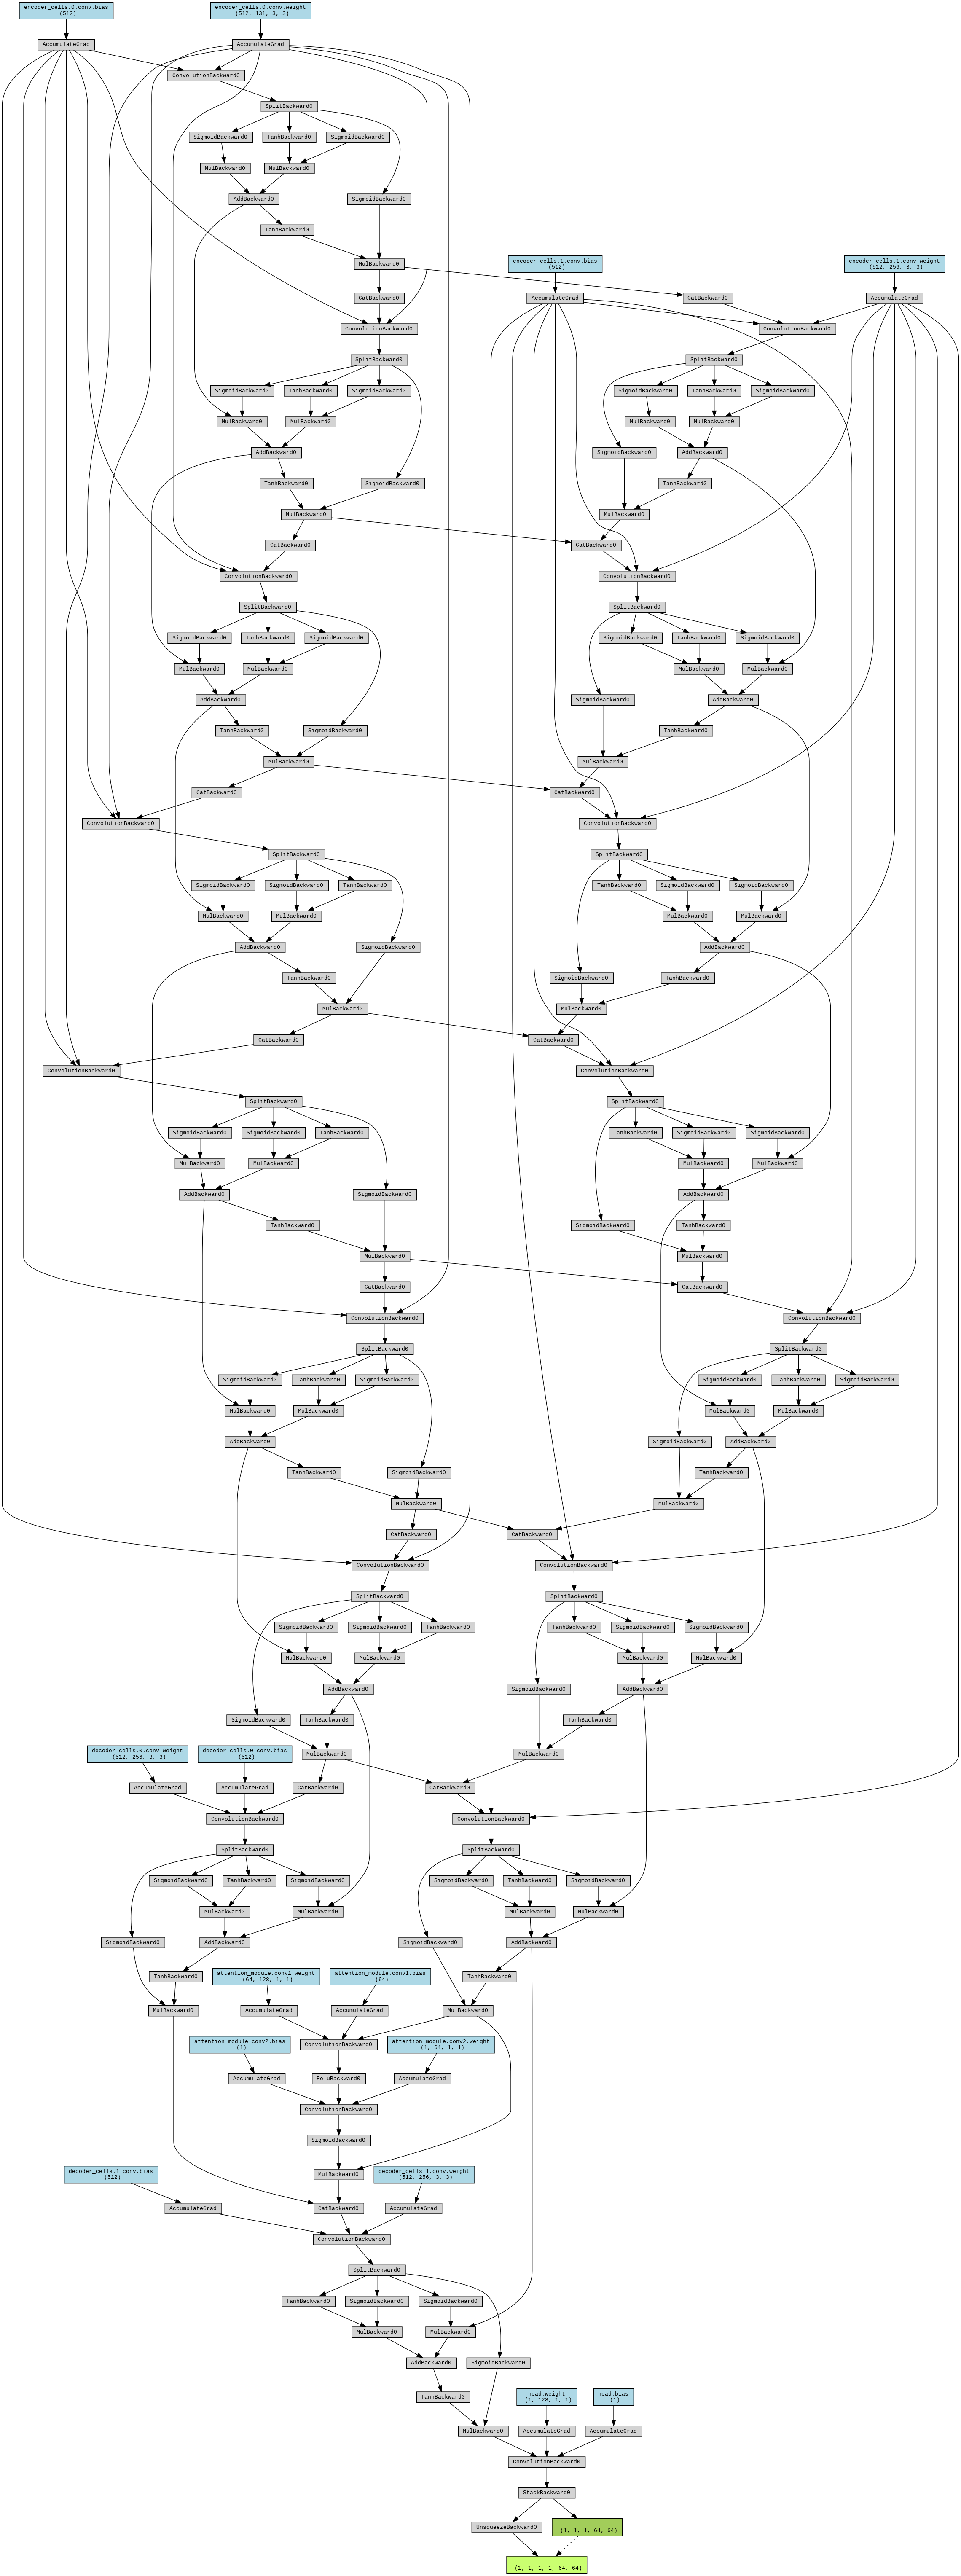

In [170]:
from torchviz import make_dot

# Ensure the model is in evaluation mode for consistent graph generation
model.eval()

# Generate a dummy input matching the model's expected input shape
# (BATCH_SIZE, SEQ_LEN, C, H, W)
dummy_input = torch.randn(BATCH_SIZE, SEQ_LEN, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

# Pass the dummy input through the model to get the output and build the graph
output = model(dummy_input)

# Create the visualization graph
dot = make_dot(output, params=dict(model.named_parameters()))

# Render and display the graph
dot.render("convlstm_model_graph", format="png", cleanup=True)
print("Model graph saved as convlstm_model_graph.png. Displaying below:")

from IPython.display import Image
Image('convlstm_model_graph.png')

### Missing Prediction Saving

The `save_predictions` function is defined, but it is currently not being called anywhere in the training, validation, or testing loops. If you want to visualize the actual predicted images during or after training, you would need to add calls to this function. For example, you could add it within `test_model` to save predictions from the test set.

### Model Visualization

Beyond `torchsummary`, if you're looking for a more graphical representation of the model's computation graph, tools like `torchviz` or integration with TensorBoard (`torch.utils.tensorboard.SummaryWriter`) can be used. These typically involve creating a dummy input and then passing it through the model while recording the graph.

In [147]:
def train_epoch(model, train_loader, opt, epoch, hist, DEVICE, loss_fn, mae, mse, rmse, calculate_psnr, calculate_ssim):
    model.train()
    train_totals = {k: 0 for k in ["loss", "mae", "mse", "rmse", "psnr", "ssim"]}
    train_cnt = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]")

    for x, y in pbar:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        pred = model(x)
        loss, mse_val, mae_val = loss_fn(pred, y)
        loss.backward()
        opt.step()

        with torch.no_grad():
            train_totals["loss"] += loss.item()
            train_totals["mae"] += mae(pred, y).item()
            train_totals["mse"] += mse(pred, y).item()
            train_totals["rmse"] += rmse(pred, y).item()
            train_totals["psnr"] += calculate_psnr(pred, y)
            train_totals["ssim"] += calculate_ssim(pred, y)
            train_cnt += 1

        pbar.set_postfix(loss=loss.item())

    for k in train_totals: hist[f"train_{k}"].append(train_totals[k] / train_cnt if train_cnt > 0 else 0)
    logging.info(f"Epoch {epoch+1} [Train] Avg Loss: {hist['train_loss'][-1]:.4f}, MAE: {hist['train_mae'][-1]:.4f}, PSNR: {hist['train_psnr'][-1]:.4f}, SSIM: {hist['train_ssim'][-1]:.4f})")

def validate_epoch(model, val_loader, epoch, hist, DEVICE, loss_fn, mae, mse, rmse, calculate_psnr, calculate_ssim):
    model.eval()
    val_totals = {k: 0 for k in ["loss", "mae", "mse", "rmse", "psnr", "ssim"]}
    val_cnt = 0
    pbar_val = tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]")

    with torch.no_grad():
        for x, y in pbar_val:
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x)
            loss, mse_val, mae_val = loss_fn(pred, y)

            val_totals["loss"] += loss.item()
            val_totals["mae"] += mae(pred, y).item()
            val_totals["mse"] += mse(pred, y).item()
            val_totals["rmse"] += rmse(pred, y).item()
            val_totals["psnr"] += calculate_psnr(pred, y)
            val_totals["ssim"] += calculate_ssim(pred, y)
            val_cnt += 1

            pbar_val.set_postfix(loss=loss.item())

    for k in val_totals: hist[f"val_{k}"].append(val_totals[k] / val_cnt if val_cnt > 0 else 0)
    logging.info(f"Epoch {epoch+1} [Val] Avg Loss: {hist['val_loss'][-1]:.4f}, MAE: {hist['val_mae'][-1]:.4f}, PSNR: {hist['val_psnr'][-1]:.4f}, SSIM: {hist['val_ssim'][-1]:.4f})")
    return hist['val_loss'][-1]

def test_model(model, test_loader, hist, DEVICE, loss_fn, mae, mse, rmse, calculate_psnr, calculate_ssim):
    model.eval()
    test_totals = {k: 0 for k in ["loss", "mae", "mse", "rmse", "psnr", "ssim"]}
    test_cnt = 0
    pbar_test = tqdm(test_loader, desc="[Test]")

    checkpoint_epoch = -1 # Default to -1 if no checkpoint is loaded
    if os.path.exists(os.path.join(CHKPOINT_DIR, "best_model.pth")):
        checkpoint = torch.load(os.path.join(CHKPOINT_DIR, "best_model.pth"))
        model.load_state_dict(checkpoint)
        checkpoint_epoch = checkpoint.get("epoch", -1) # Retrieve epoch from checkpoint
        logging.info(f"Loaded best model from epoch {checkpoint_epoch} for testing.")

    with torch.no_grad():
        for x, y in pbar_test:
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x)
            loss, mse_val, mae_val = loss_fn(pred, y)

            test_totals["loss"] += loss.item()
            test_totals["mae"] += mae(pred, y).item()
            test_totals["mse"] += mse(pred, y).item()
            test_totals["rmse"] += rmse(pred, y).item()
            test_totals["psnr"] += calculate_psnr(pred, y)
            test_totals["ssim"] += calculate_ssim(pred, y)
            test_cnt += 1

            # Call save_predictions here for the test set
            save_predictions(pred, y, checkpoint_epoch, split_name="test")

            pbar_test.set_postfix(loss=loss.item())

    for k in test_totals: hist[f"test_{k}"].append(test_totals[k] / test_cnt if test_cnt > 0 else 0)
    logging.info(f"[Test] Avg Loss: {hist['test_loss'][-1]:.4f}, MAE: {hist['test_mae'][-1]:.4f}, PSNR: {hist['test_psnr'][-1]:.4f}, SSIM: {hist['test_ssim'][-1]:.4f})")

In [148]:
def run_experiment(max_images=None):
    logging.info("Loading and preparing data...")
    # Get all image paths from subdirectories within DATA_ROOT (MONTH/DAY/*.png)
    all_image_paths = sorted(glob.glob(f"{DATA_ROOT}/*/*/*.png"))

    if max_images is not None:
        all_image_paths = all_image_paths[:max_images]

    # Split data into train, validation, and test sets
    train_paths, test_paths = train_test_split(all_image_paths, test_size=TEST_SPLIT, random_state=SEED)
    train_paths, val_paths = train_test_split(train_paths, test_size=VAL_SPLIT/(TRAIN_SPLIT+VAL_SPLIT), random_state=SEED)

    logging.info(f"Total images: {len(all_image_paths)}")
    logging.info(f"Train images: {len(train_paths)}")
    logging.info(f"Validation images: {len(val_paths)}")
    logging.info(f"Test images: {len(test_paths)}")

    # Create datasets and dataloaders
    train_dataset = SpatioTemporalDataset(train_paths)
    val_dataset = SpatioTemporalDataset(val_paths)
    test_dataset = SpatioTemporalDataset(test_paths)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    logging.info("Initializing model, optimizer, and history...")
    model = ConvLSTMModel().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    hist = {k: [] for k in [
        "train_loss", "train_mae", "train_mse", "train_rmse", "train_psnr", "train_ssim",
        "val_loss", "val_mae", "val_mse", "val_rmse", "val_psnr", "val_ssim",
        "test_loss", "test_mae", "test_mse", "test_rmse", "test_psnr", "test_ssim"
    ]}

    best_val_loss = float('inf')
    patience = 5
    epochs_no_improve = 0

    logging.info("Starting training process...")
    for epoch in range(EPOCHS):
        train_epoch(model, train_loader, opt, epoch, hist, DEVICE, loss_fn, mae, mse, rmse, calculate_psnr, calculate_ssim)
        val_loss = validate_epoch(model, val_loader, epoch, hist, DEVICE, loss_fn, mae, mse, rmse, calculate_psnr, calculate_ssim)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            save_ckpt(model, opt, epoch, is_best=True)
            logging.info(f"Validation loss improved. Best model saved at epoch {epoch+1}.")
        else:
            epochs_no_improve += 1
            logging.info(f"Validation loss did not improve. Patience: {epochs_no_improve}/{patience}")

        save_ckpt(model, opt, epoch) # Save checkpoint for every epoch

        if epochs_no_improve == patience:
            logging.info(f"Early stopping triggered after {patience} epochs without improvement.")
            break

    logging.info("Training complete. Running final evaluation on test set...")
    test_model(model, test_loader, hist, DEVICE, loss_fn, mae, mse, rmse, calculate_psnr, calculate_ssim)
    logging.info("Project finished.")

    return hist # Return the history dictionary

In [160]:
if __name__ == "__main__":
    logging.info('----------------------------------------------------------------')
    logging.info("Starting Project...")
    logging.info(f"Run No. {runno}")
    logging.info("Configurations: ")
    logging.info("Sequence length of images taken "+ str(SEQ_LEN))
    logging.info("Current Batch Size taken " + str(BATCH_SIZE))
    logging.info("Number of Epochs in the run "+str(EPOCHS))
    logging.info("Current training image resolution " + str(IMG_SIZE))
    logging.info("Learning Rate "+str(LR))
    logging.info(f"DEVICE {DEVICE}")
    set_seed(SEED)

    # Explicitly define split constants here to ensure they are available
    # if the previous configuration cell was not executed or updated.
    TRAIN_SPLIT = 0.7
    VAL_SPLIT = 0.15
    TEST_SPLIT = 0.15 # Remaining for test (0.15)

    # Set this to a number (e.g., 200) to limit the total images for debugging,
    # or None to use all available images.
    DEBUG_MAX_IMAGES = 60 # Changed from 35 to ensure validation and test sets are not empty

    try:
        global hist # Declare hist as global
        hist = run_experiment(max_images=DEBUG_MAX_IMAGES) # Capture the returned hist dictionary
    except Exception as e:
        logging.exception(f"Fatal error: {e}")

[Test]: 100%|██████████| 1/1 [00:00<00:00,  2.43it/s, loss=0.0265]


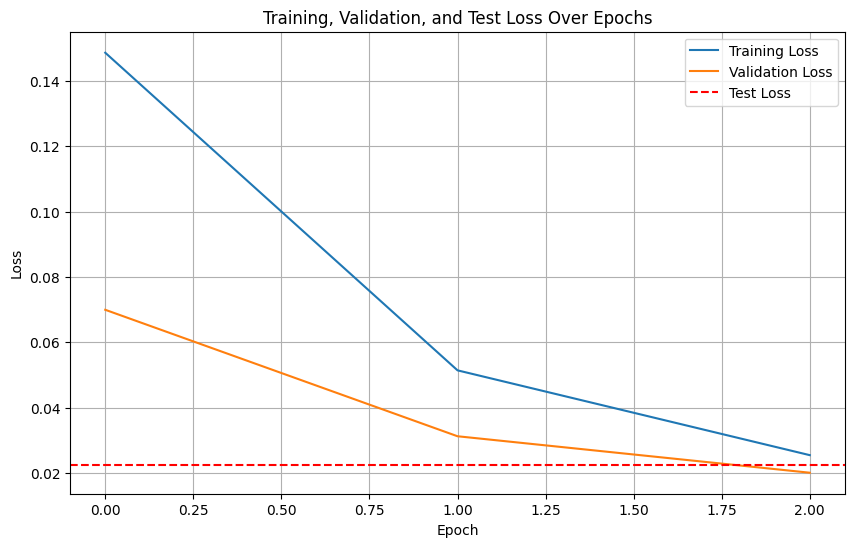

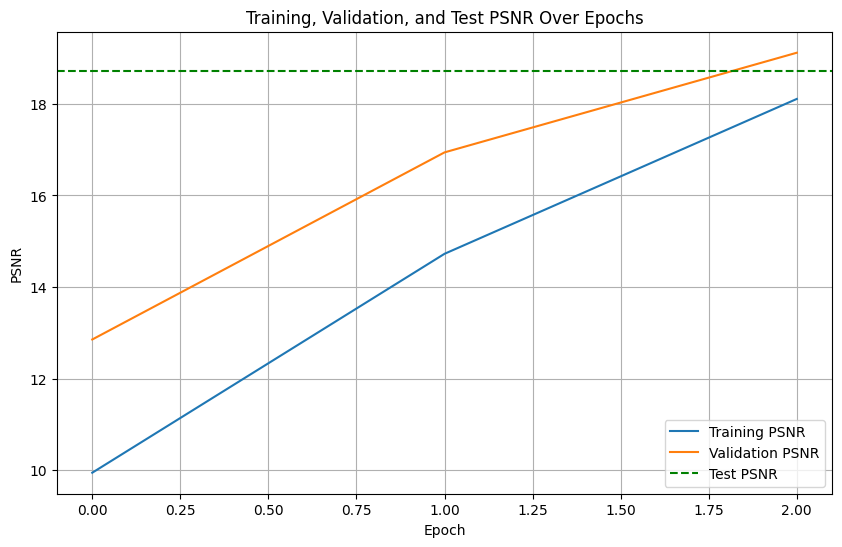

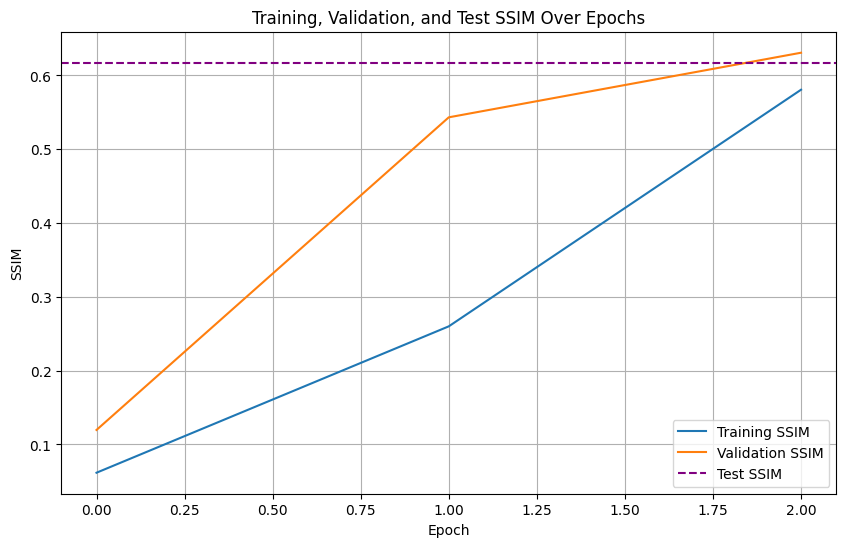

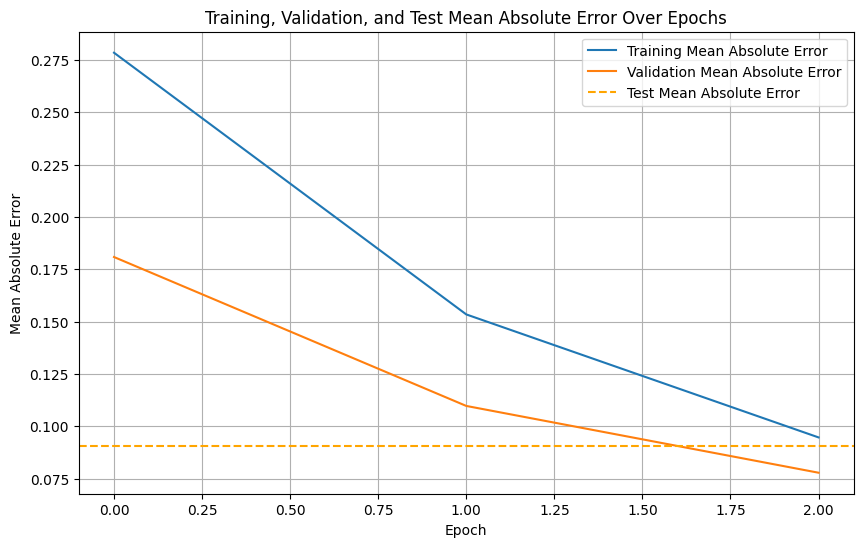

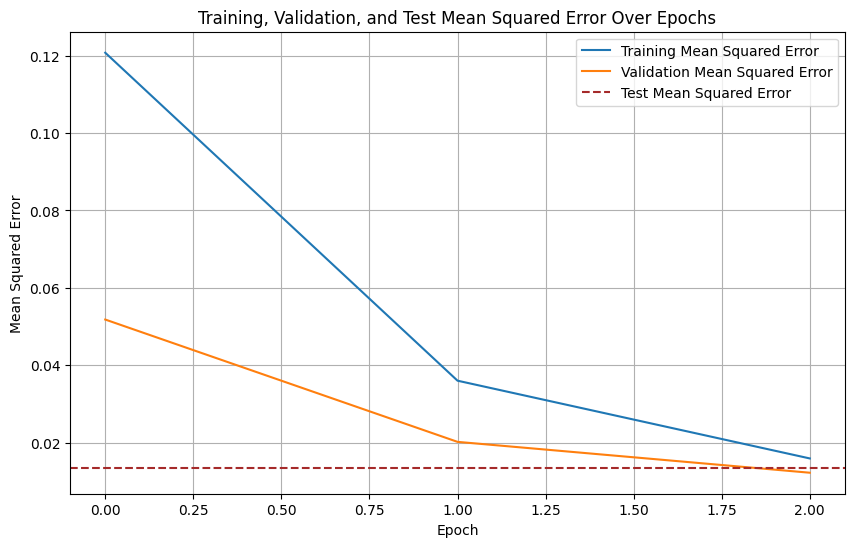

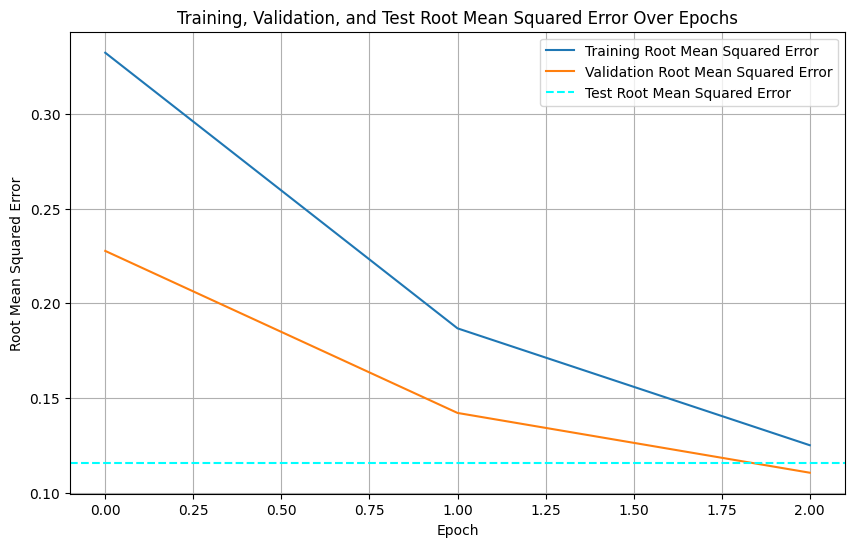

In [150]:
# Call the plotting function after the experiment completes
if 'hist' in globals() and hist:
    plot_metrics(hist)
else:
    logging.error("History (hist) dictionary not found or is empty. Cannot plot metrics.")


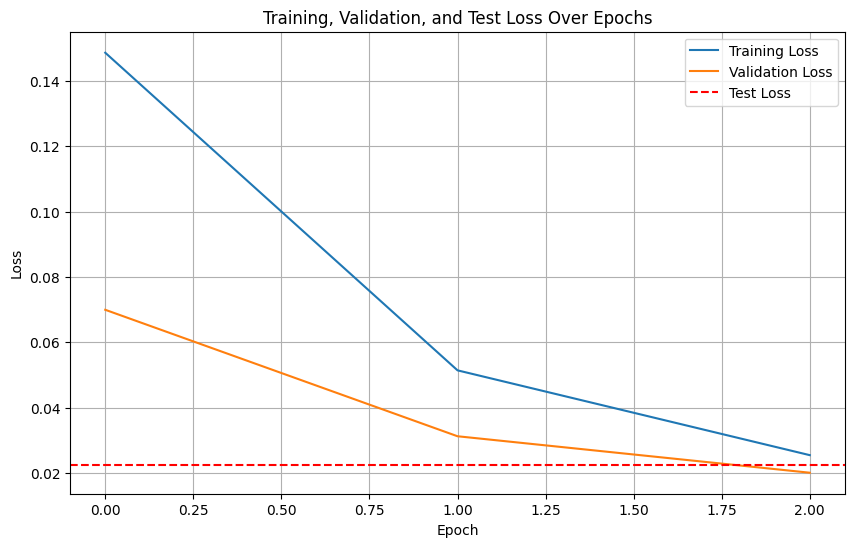

In [151]:
import matplotlib.pyplot as plt

# Plotting the loss curves
plt.figure(figsize=(10, 6))
plt.plot(hist['train_loss'], label='Training Loss')
plt.plot(hist['val_loss'], label='Validation Loss')
# Check if test_loss is available and plot it
if hist['test_loss']:
    # Assuming test_loss is a single value after the experiment, or a list like others
    # For a single value, plot it as a horizontal line or a point
    if len(hist['test_loss']) == 1:
        plt.axhline(y=hist['test_loss'][0], color='r', linestyle='--', label='Test Loss')
    else:
        plt.plot(hist['test_loss'], label='Test Loss')

plt.title('Training, Validation, and Test Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

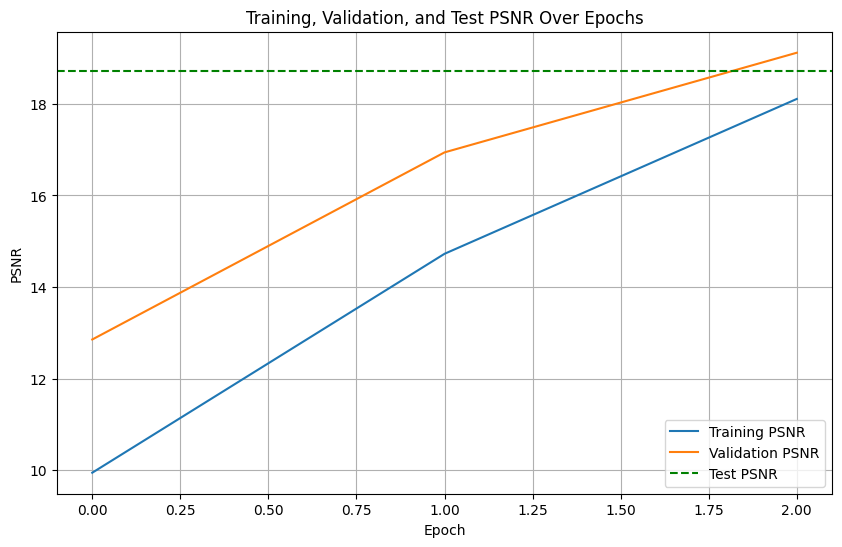

In [152]:
import matplotlib.pyplot as plt

# Plotting PSNR curves
plt.figure(figsize=(10, 6))
plt.plot(hist['train_psnr'], label='Training PSNR')
plt.plot(hist['val_psnr'], label='Validation PSNR')
# Check if test_psnr is available and plot it
if hist['test_psnr']:
    if len(hist['test_psnr']) == 1:
        plt.axhline(y=hist['test_psnr'][0], color='g', linestyle='--', label='Test PSNR')
    else:
        plt.plot(hist['test_psnr'], label='Test PSNR')

plt.title('Training, Validation, and Test PSNR Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('PSNR')
plt.legend()
plt.grid(True)
plt.show()

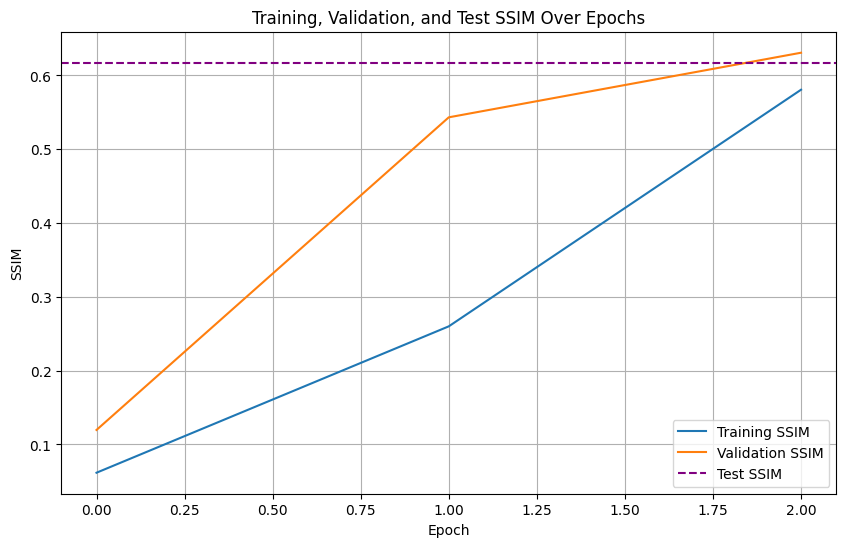

In [153]:
import matplotlib.pyplot as plt

# Plotting SSIM curves
plt.figure(figsize=(10, 6))
plt.plot(hist['train_ssim'], label='Training SSIM')
plt.plot(hist['val_ssim'], label='Validation SSIM')
# Check if test_ssim is available and plot it
if hist['test_ssim']:
    if len(hist['test_ssim']) == 1:
        plt.axhline(y=hist['test_ssim'][0], color='purple', linestyle='--', label='Test SSIM')
    else:
        plt.plot(hist['test_ssim'], label='Test SSIM')

plt.title('Training, Validation, and Test SSIM Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('SSIM')
plt.legend()
plt.grid(True)
plt.show()

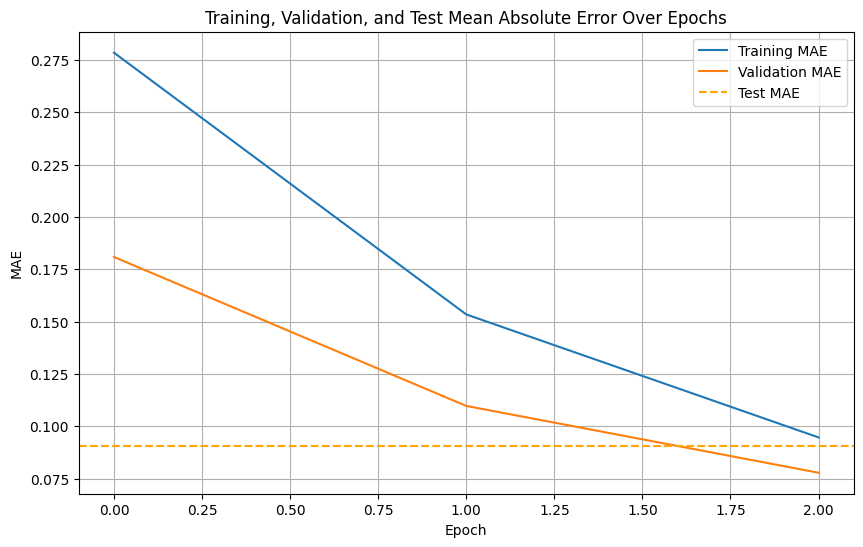

In [154]:
import matplotlib.pyplot as plt

# Plotting MAE curves
plt.figure(figsize=(10, 6))
plt.plot(hist['train_mae'], label='Training MAE')
plt.plot(hist['val_mae'], label='Validation MAE')
# Check if test_mae is available and plot it
if hist['test_mae']:
    if len(hist['test_mae']) == 1:
        plt.axhline(y=hist['test_mae'][0], color='orange', linestyle='--', label='Test MAE')
    else:
        plt.plot(hist['test_mae'], label='Test MAE')

plt.title('Training, Validation, and Test Mean Absolute Error Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()

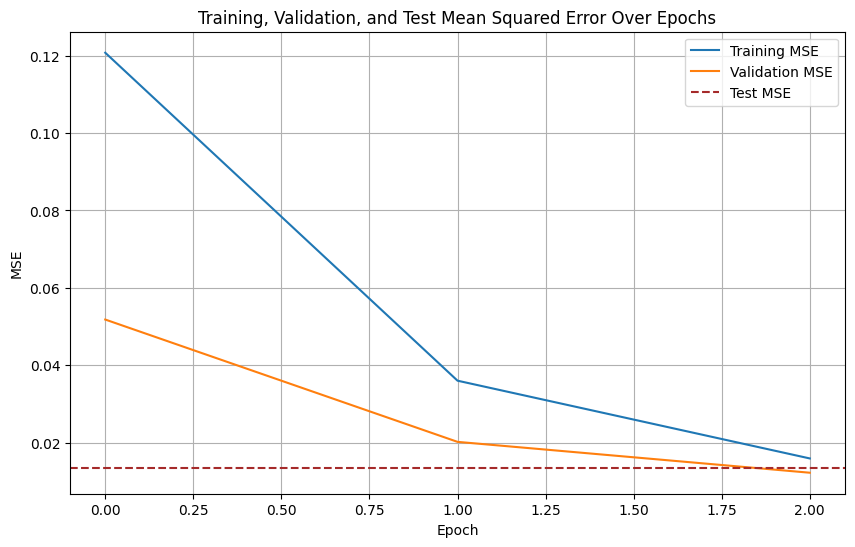

In [155]:
import matplotlib.pyplot as plt

# Plotting MSE curves
plt.figure(figsize=(10, 6))
plt.plot(hist['train_mse'], label='Training MSE')
plt.plot(hist['val_mse'], label='Validation MSE')
# Check if test_mse is available and plot it
if hist['test_mse']:
    if len(hist['test_mse']) == 1:
        plt.axhline(y=hist['test_mse'][0], color='brown', linestyle='--', label='Test MSE')
    else:
        plt.plot(hist['test_mse'], label='Test MSE')

plt.title('Training, Validation, and Test Mean Squared Error Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

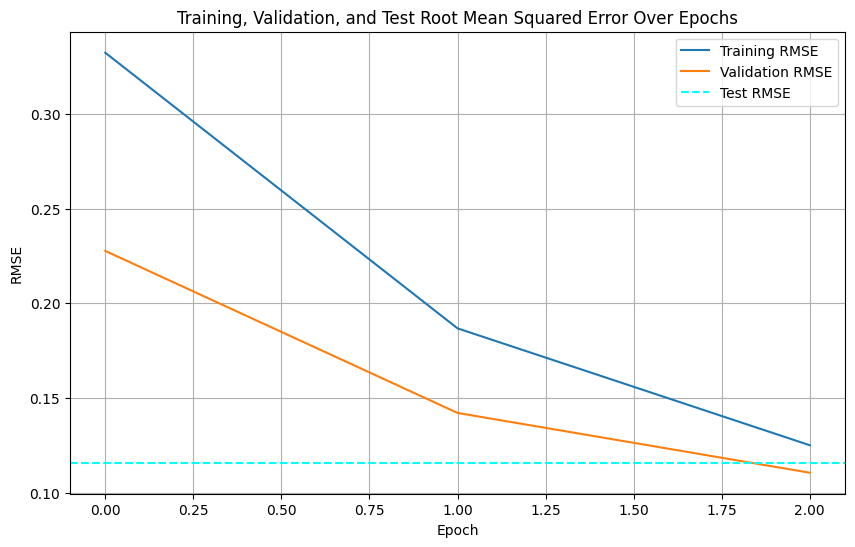

In [156]:
import matplotlib.pyplot as plt

# Plotting RMSE curves
plt.figure(figsize=(10, 6))
plt.plot(hist['train_rmse'], label='Training RMSE')
plt.plot(hist['val_rmse'], label='Validation RMSE')
# Check if test_rmse is available and plot it
if hist['test_rmse']:
    if len(hist['test_rmse']) == 1:
        plt.axhline(y=hist['test_rmse'][0], color='cyan', linestyle='--', label='Test RMSE')
    else:
        plt.plot(hist['test_rmse'], label='Test RMSE')

plt.title('Training, Validation, and Test Root Mean Squared Error Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.show()